# Analisis Prediksi Kinerja Mahasiswa (Student Performance Evaluation)

Dataset ini berasal dari **Fakultas Teknik dan Fakultas Ilmu Pendidikan tahun 2019** (UCI ID: 856). 
Tujuan utama dari analisis ini adalah untuk memprediksi kinerja mahasiswa di akhir semester menggunakan teknik *Machine Learning* untuk pemodelan klasifikasi.

Dalam *notebook* ini, kita menyempurnakan analisis dengan menerapkan:
1. Statistik Deskriptif untuk pemahaman data awal yang lebih mendalam.
2. Pembagian data latih-uji menggunakan **Stratified Split** untuk menjaga keseimbangan kelas target pada dataset berukuran kecil (145 data).
3. Penerapan normalisasi data secara **selektif** (hanya pada algoritma jarak/margin seperti KNN dan SVM).
4. **Hyperparameter Tuning** menggunakan `GridSearchCV` untuk mengoptimalkan kinerja masing-masing model.
5. Evaluasi kestabilan model menggunakan **5-Fold Cross Validation**.
6. Analisis kontribusi fitur melalui **Feature Importance** dari model Random Forest terbaik.


In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# Models
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")


## 1. Data Loading & Statistik Deskriptif

Kita menggunakan package `ucimlrepo` untuk mengimpor dataset secara langsung.


In [47]:
# Fetch dataset 
dataset = fetch_ucirepo(id=856) 

# Menyimpan fitur dan target dalam DataFrame
X = dataset.data.features 
y = dataset.data.targets 

print(f"Jumlah Fitur: {X.shape[1]}")
print(f"Jumlah Baris: {X.shape[0]}")
X.head()


Jumlah Fitur: 31
Jumlah Baris: 145


,Student Age,Sex,Graduated high-school type,Scholarship type,Additional work,Regular artistic or sports activity,Do you have a partner,Total salary if available,Transportation to the university,Accomodation type in Cyprus,...,Attendance to classes,Preparation to midterm exams 1,Preparation to midterm exams 2,Taking notes in classes,Listening in classes,Discussion improves my interest and success in the course,Flip-classroom,Cumulative grade point average in the last semester (/4.00),Expected Cumulative grade point average in the graduation (/4.00),Course ID
0,2,2,3,3,1,2,2,1,1,1,...,1,1,1,3,2,1,2,1,1,1
1,2,2,3,3,1,2,2,1,1,1,...,1,1,1,3,2,3,2,2,3,1
2,2,2,2,3,2,2,2,2,4,2,...,1,1,1,2,2,1,1,2,2,1
3,1,1,1,3,1,2,1,2,1,2,...,1,1,2,3,2,2,1,3,2,1
4,2,2,1,3,2,2,1,3,1,4,...,1,2,1,2,2,2,1,2,2,1


### 1.1 Analisis Statistik Deskriptif

Bagian ini penting dalam EDA untuk melihat ringkasan statistik dari masing-masing fitur numerik/ordinal, termasuk rata-rata (*mean*), standar deviasi, nilai minimum, maksimum, serta nilai kuartilnya.


In [48]:
# Menampilkan ringkasan statistik deskriptif untuk fitur
X.describe().T


,count,mean,std,min,25%,50%,75%,max
Student Age,145.0,1.620690,0.613154,1.0,1.0,2.0,2.0,3.0
Sex,145.0,1.600000,0.491596,1.0,1.0,2.0,2.0,2.0
Graduated high-school type,145.0,1.944828,0.537216,1.0,2.0,2.0,2.0,3.0
Scholarship type,145.0,3.572414,0.805750,1.0,3.0,3.0,4.0,5.0
Additional work,145.0,1.662069,0.474644,1.0,1.0,2.0,2.0,2.0
Regular artistic or sports activity,145.0,1.600000,0.491596,1.0,1.0,2.0,2.0,2.0
Do you have a partner,145.0,1.579310,0.495381,1.0,1.0,2.0,2.0,2.0
Total salary if available,145.0,1.627586,1.020245,1.0,1.0,1.0,2.0,5.0
Transportation to the university,145.0,1.620690,1.061112,1.0,1.0,1.0,2.0,4.0
Accomodation type in Cyprus,145.0,1.731034,0.783999,1.0,1.0,2.0,2.0,4.0


## 2. Data Mapping & Exploratory Data Analysis (EDA)

Kolom pada dataset ini berisikan angka yang merepresentasikan kategori tertentu. Agar proses analisis secara visual (EDA) lebih mudah dimengerti, kita akan memetakan (*mapping*) angka-angka tersebut ke dalam teks sesuai dengan kamus data (metadata) resminya.


In [49]:
mapping_dict = {
    'Student Age': {1: '18-21', 2: '22-25', 3: 'above 26'},
    'Sex': {1: 'female', 2: 'male'},
    'Graduated high-school type': {1: 'private', 2: 'state', 3: 'other'},
    'Scholarship type': {1: 'None', 2: '25%', 3: '50%', 4: '75%', 5: 'Full'},
    'Additional work': {1: 'Yes', 2: 'No'},
    'Regular artistic or sports activity': {1: 'Yes', 2: 'No'},
    'Do you have a partner': {1: 'Yes', 2: 'No'},
    'Total salary if available': {1: 'USD 135-200', 2: 'USD 201-270', 3: 'USD 271-340', 4: 'USD 341-410', 5: 'above 410'},
    'Transportation to the university': {1: 'Bus', 2: 'Private car/taxi', 3: 'bicycle', 4: 'Other'},
    'Accomodation type in Cyprus': {1: 'rental', 2: 'dormitory', 3: 'with family', 4: 'Other'},
    "Mother's education": {1: 'primary school', 2: 'secondary school', 3: 'high school', 4: 'university', 5: 'MSc.', 6: 'Ph.D.'},
    "Father's education": {1: 'primary school', 2: 'secondary school', 3: 'high school', 4: 'university', 5: 'MSc.', 6: 'Ph.D.'},
    'Number of sisters/brothers (if available)': {1: '1', 2: '2', 3: '3', 4: '4', 5: '5 or above'},
    'Parental status': {1: 'married', 2: 'divorced', 3: 'died'},
    "Mother's occupation": {1: 'retired', 2: 'housewife', 3: 'government officer', 4: 'private sector employee', 5: 'self-employment', 6: 'other'},
    "Father's occupation": {1: 'retired', 2: 'government officer', 3: 'private sector employee', 4: 'self-employment', 5: 'other'},
    'Weekly study hours': {1: 'None', 2: '<5 hours', 3: '6-10 hours', 4: '11-20 hours', 5: 'more than 20 hours'},
    'Reading frequency (non-scientific books/journals)': {1: 'None', 2: 'Sometimes', 3: 'Often'},
    'Reading frequency (scientific books/journals)': {1: 'None', 2: 'Sometimes', 3: 'Often'},
    'Attendance to the seminars/conferences related to the department': {1: 'Yes', 2: 'No'},
    'Impact of your projects/activities on your success': {1: 'positive', 2: 'negative', 3: 'neutral'},
    'Attendance to classes': {1: 'always', 2: 'sometimes', 3: 'never'},
    'Preparation to midterm exams 1': {1: 'alone', 2: 'with friends', 3: 'not applicable'},
    'Preparation to midterm exams 2': {1: 'closest date', 2: 'regularly', 3: 'never'},
    'Taking notes in classes': {1: 'never', 2: 'sometimes', 3: 'always'},
    'Listening in classes': {1: 'never', 2: 'sometimes', 3: 'always'},
    'Discussion improves my interest and success in the course': {1: 'never', 2: 'sometimes', 3: 'always'},
    'Flip-classroom': {1: 'not useful', 2: 'useful', 3: 'not applicable'},
    'Cumulative grade point average in the last semester (/4.00)': {1: '<2.00', 2: '2.00-2.49', 3: '2.50-2.99', 4: '3.00-3.49', 5: 'above 3.49'},
    'Expected Cumulative grade point average in the graduation (/4.00)': {1: '<2.00', 2: '2.00-2.49', 3: '2.50-2.99', 4: '3.00-3.49', 5: 'above 3.49'}
}

# Membuat DataFrame khusus untuk EDA agar fitur asli tidak berubah
X_eda = X.copy()
for col, mapping in mapping_dict.items():
    if col in X_eda.columns:
        X_eda[col] = X_eda[col].map(mapping)

y_eda = y.copy()
y_mapping = {0: 'Fail', 1: 'DD', 2: 'DC', 3: 'CC', 4: 'CB', 5: 'BB', 6: 'BA', 7: 'AA'}
y_eda['OUTPUT Grade'] = y_eda['OUTPUT Grade'].map(y_mapping)

df_eda = pd.concat([X_eda, y_eda], axis=1)
df_eda.head()


,Student Age,Sex,Graduated high-school type,Scholarship type,Additional work,Regular artistic or sports activity,Do you have a partner,Total salary if available,Transportation to the university,Accomodation type in Cyprus,...,Preparation to midterm exams 1,Preparation to midterm exams 2,Taking notes in classes,Listening in classes,Discussion improves my interest and success in the course,Flip-classroom,Cumulative grade point average in the last semester (/4.00),Expected Cumulative grade point average in the graduation (/4.00),Course ID,OUTPUT Grade
0,22-25,male,other,50%,Yes,No,No,USD 135-200,Bus,rental,...,alone,closest date,always,sometimes,never,useful,<2.00,<2.00,1,DD
1,22-25,male,other,50%,Yes,No,No,USD 135-200,Bus,rental,...,alone,closest date,always,sometimes,always,useful,2.00-2.49,2.50-2.99,1,DD
2,22-25,male,state,50%,No,No,No,USD 201-270,Other,dormitory,...,alone,closest date,sometimes,sometimes,never,not useful,2.00-2.49,2.00-2.49,1,DD
3,18-21,female,private,50%,Yes,No,Yes,USD 201-270,Bus,dormitory,...,alone,regularly,always,sometimes,sometimes,not useful,2.50-2.99,2.00-2.49,1,DD
4,22-25,male,private,50%,No,No,Yes,USD 271-340,Bus,Other,...,with friends,closest date,sometimes,sometimes,sometimes,not useful,2.00-2.49,2.00-2.49,1,DD


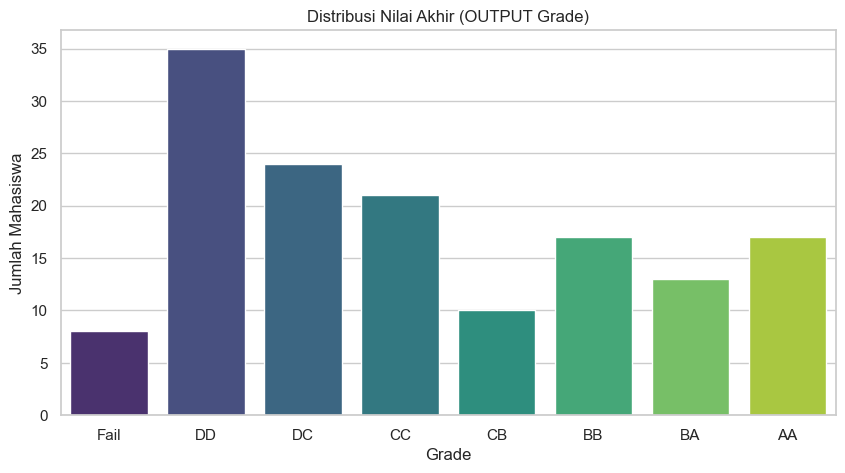

In [50]:
# Distribusi Nilai Akhir
plt.figure(figsize=(10, 5))
sns.countplot(data=df_eda, x='OUTPUT Grade', order=y_mapping.values(), palette='viridis')
plt.title("Distribusi Nilai Akhir (OUTPUT Grade)")
plt.ylabel("Jumlah Mahasiswa")
plt.xlabel("Grade")
plt.show()


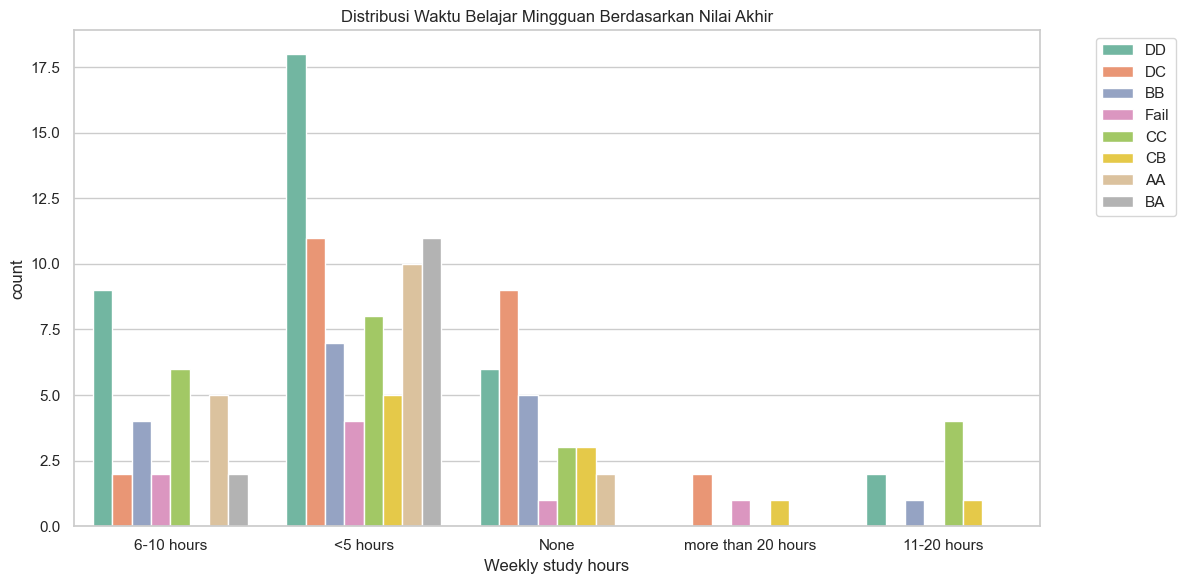

In [51]:
# Pengaruh Waktu Belajar Mingguan terhadap Nilai
plt.figure(figsize=(12, 6))
sns.countplot(data=df_eda, x='Weekly study hours', hue='OUTPUT Grade', palette='Set2')
plt.title("Distribusi Waktu Belajar Mingguan Berdasarkan Nilai Akhir")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


## 3. Data Preprocessing & Splitting

Langkah yang dilakukan:
1. Membagi data menggunakan **Stratified Split** (`stratify=y_val`) agar proporsi kelas target pada data latih (*Training*) dan data uji (*Testing*) tetap seimbang, terutama karena ukuran dataset kecil (145 data).
2. Melakukan Standarisasi Data (*Z-Score Normalization*) menggunakan `StandardScaler` **hanya** untuk model berbasis jarak/margin (KNN & SVM). Model berbasis pohon (Decision Tree & Random Forest) dan Naive Bayes akan menggunakan data asli untuk menghindari manipulasi data yang tidak diperlukan.


In [52]:
# Memisahkan data dengan stratifikasi
y_val = y.values.ravel()
X_train, X_test, y_train, y_test = train_test_split(X, y_val, test_size=0.2, random_state=42, stratify=y_val)

print(f"Data Training: {X_train.shape[0]} baris")
print(f"Data Testing: {X_test.shape[0]} baris")

# Standarisasi Data (khusus untuk KNN & SVM)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


Data Training: 116 baris
Data Testing: 29 baris


## 4. Pemodelan (Modeling) & Hyperparameter Tuning

Kita akan melatih, mengoptimalkan (tuning), dan mengevaluasi 5 model klasifikasi menggunakan Cross Validation untuk memitigasi variansi pada data yang sedikit.


In [53]:
# Kamus untuk menyimpan skor akurasi testing dan skor CV rata-rata
model_test_accuracies = {}
model_cv_scores = {}

# Fungsi bantuan untuk melatih, memprediksi, dan mengevaluasi model
def train_and_evaluate(model_name, tuned_model, X_tr, X_ts, use_cv_pipeline=False):
    # Latih model
    tuned_model.fit(X_tr, y_train)
    
    # Prediksi
    y_pred = tuned_model.predict(X_ts)
    acc = accuracy_score(y_test, y_pred)
    model_test_accuracies[model_name] = acc
    
    # Cross Validation
    if use_cv_pipeline:
        # Untuk KNN/SVM gunakan pipeline agar scaling aman dari leakage
        pipeline = make_pipeline(StandardScaler(), tuned_model)
        cv_score = cross_val_score(pipeline, X, y_val, cv=5).mean()
    else:
        cv_score = cross_val_score(tuned_model, X, y_val, cv=5).mean()
    model_cv_scores[model_name] = cv_score
    
    # Print Evaluasi Lengkap
    print(f"==================== {model_name} ====================")
    print(f"Tuned Parameters: {tuned_model.get_params()}")
    print(f"Akurasi Pengujian (Test): {acc * 100:.2f}%")
    print(f"Mean CV Accuracy (5-Fold): {cv_score * 100:.2f}%\n")
    print("Classification Report:")
    print(classification_report(y_test, y_pred, zero_division=0))
    
    # Plot Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=[y_mapping[i] for i in range(8)], 
                yticklabels=[y_mapping[i] for i in range(8)])
    plt.title(f'Confusion Matrix: {model_name}')
    plt.xlabel('Prediksi')
    plt.ylabel('Aktual')
    plt.tight_layout()
    plt.show()
    
    return tuned_model


### 4.1 Naive Bayes (GaussianNB)
Model Naive Bayes tidak memerlukan scaling dan tidak memiliki hyperparameter utama untuk dituning. Kita latih dengan parameter default.


==================== Naive Bayes ====================
Tuned Parameters: {'priors': None, 'var_smoothing': 1e-09}
Akurasi Pengujian (Test): 13.79%
Mean CV Accuracy (5-Fold): 15.86%

Classification Report:
              precision    recall  f1-score   support

           0       0.33      1.00      0.50         2
           1       0.00      0.00      0.00         7
           2       0.00      0.00      0.00         5
           3       0.00      0.00      0.00         4
           4       0.00      0.00      0.00         2
           5       0.00      0.00      0.00         3
           6       0.29      0.67      0.40         3
           7       0.00      0.00      0.00         3

    accuracy                           0.14        29
   macro avg       0.08      0.21      0.11        29
weighted avg       0.05      0.14      0.08        29



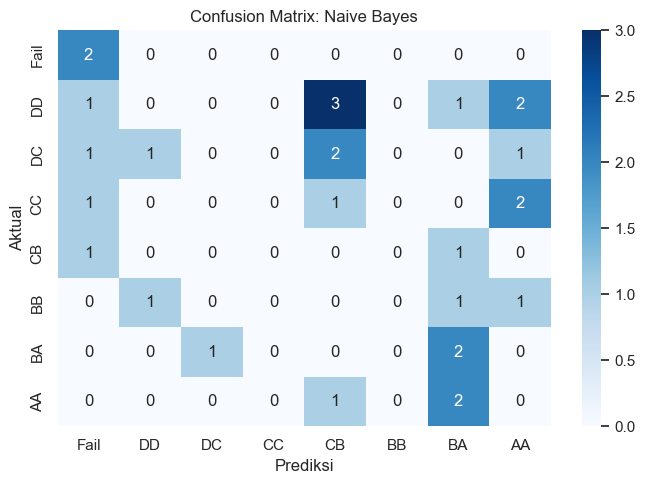

In [54]:
nb_base = GaussianNB()
nb_tuned = train_and_evaluate("Naive Bayes", nb_base, X_train, X_test)


### 4.2 Decision Tree (Tuned)
Kita akan mencari parameter terbaik untuk `max_depth` dan `criterion` guna mencegah overfitting.


==================== Decision Tree ====================
Tuned Parameters: {'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': 10, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'random_state': 42, 'splitter': 'best'}
Akurasi Pengujian (Test): 31.03%
Mean CV Accuracy (5-Fold): 20.69%

Classification Report:
              precision    recall  f1-score   support

           0       0.50      0.50      0.50         2
           1       0.44      0.57      0.50         7
           2       0.25      0.20      0.22         5
           3       0.17      0.25      0.20         4
           4       0.00      0.00      0.00         2
           5       0.00      0.00      0.00         3
           6       0.50      0.33      0.40         3
           7       1.00      0.33      0.50         3

    accuracy                           0.31      

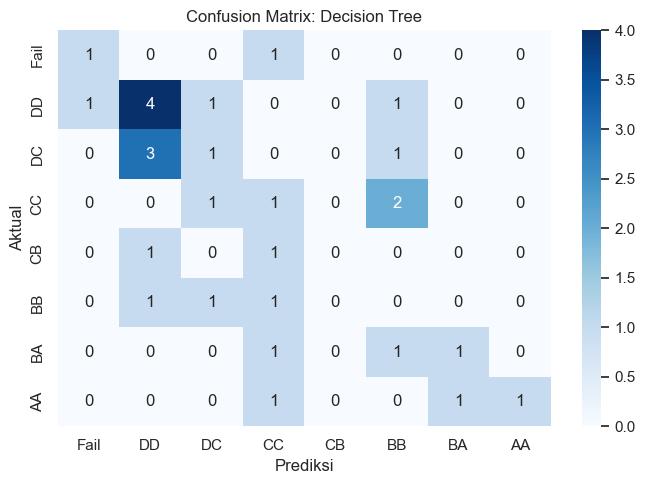

,criterion,'gini'
,splitter,'best'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [55]:
param_grid_dt = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10]
}
grid_dt = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid_dt, cv=5, scoring='accuracy')
grid_dt.fit(X_train, y_train)

dt_tuned = grid_dt.best_estimator_
train_and_evaluate("Decision Tree", dt_tuned, X_train, X_test)


### 4.3 Random Forest (Tuned)
Model ensemble berbasis pohon ini dituning pada parameter jumlah pohon (`n_estimators`) dan kedalaman pohon (`max_depth`).


==================== Random Forest ====================
Tuned Parameters: {'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': 5, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 50, 'n_jobs': None, 'oob_score': False, 'random_state': 42, 'verbose': 0, 'warm_start': False}
Akurasi Pengujian (Test): 34.48%
Mean CV Accuracy (5-Fold): 28.28%

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         2
           1       0.35      1.00      0.52         7
           2       1.00      0.20      0.33         5
           3       0.20      0.25      0.22         4
           4       0.00      0.00      0.00         2
           5       0.00      0.00      0.00         3
           6       0.33      0.33      0.33   

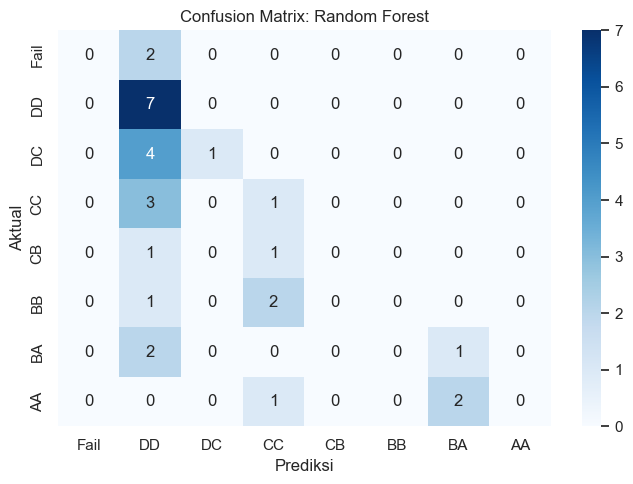

,n_estimators,50
,criterion,'gini'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [56]:
param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10]
}
grid_rf = GridSearchCV(RandomForestClassifier(random_state=42), param_grid_rf, cv=5, scoring='accuracy')
grid_rf.fit(X_train, y_train)

rf_tuned = grid_rf.best_estimator_
train_and_evaluate("Random Forest", rf_tuned, X_train, X_test)


### 4.4 K-Nearest Neighbors (KNN - Tuned & Scaled)
Model KNN membutuhkan data terskala (`StandardScaler`) agar perhitungan jarak Euclidean adil. Kita tuning jumlah tetangga (`n_neighbors`).


==================== K-Nearest Neighbors ====================
Tuned Parameters: {'algorithm': 'auto', 'leaf_size': 30, 'metric': 'minkowski', 'metric_params': None, 'n_jobs': None, 'n_neighbors': 3, 'p': 2, 'weights': 'distance'}
Akurasi Pengujian (Test): 24.14%
Mean CV Accuracy (5-Fold): 20.69%

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         2
           1       0.43      0.43      0.43         7
           2       0.00      0.00      0.00         5
           3       0.40      0.50      0.44         4
           4       0.00      0.00      0.00         2
           5       0.22      0.67      0.33         3
           6       0.00      0.00      0.00         3
           7       0.00      0.00      0.00         3

    accuracy                           0.24        29
   macro avg       0.13      0.20      0.15        29
weighted avg       0.18      0.24      0.20        29



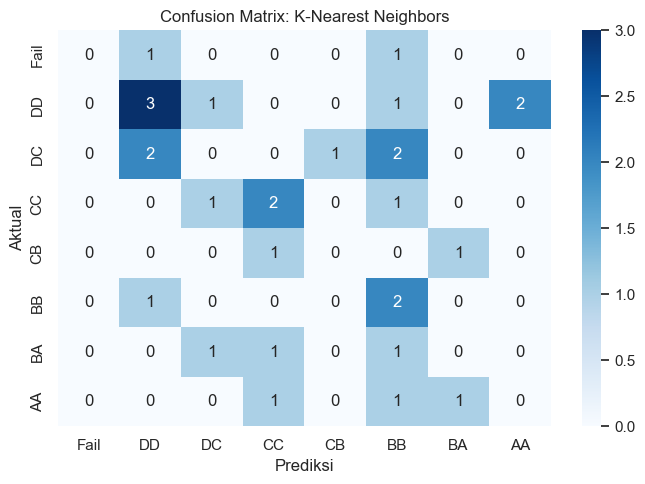

,n_neighbors,3
,weights,'distance'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [57]:
param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance']
}
grid_knn = GridSearchCV(KNeighborsClassifier(), param_grid_knn, cv=5, scoring='accuracy')
grid_knn.fit(X_train_scaled, y_train)

knn_tuned = grid_knn.best_estimator_
train_and_evaluate("K-Nearest Neighbors", knn_tuned, X_train_scaled, X_test_scaled, use_cv_pipeline=True)


### 4.5 Support Vector Machine (SVM - Tuned & Scaled)
Model SVM membutuhkan data terskala. Kita tuning penalti `C` dan parameter `kernel`.


==================== Support Vector Machine ====================
Tuned Parameters: {'C': 0.1, 'break_ties': False, 'cache_size': 200, 'class_weight': None, 'coef0': 0.0, 'decision_function_shape': 'ovr', 'degree': 3, 'gamma': 'scale', 'kernel': 'rbf', 'max_iter': -1, 'probability': False, 'random_state': 42, 'shrinking': True, 'tol': 0.001, 'verbose': False}
Akurasi Pengujian (Test): 24.14%
Mean CV Accuracy (5-Fold): 24.14%

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         2
           1       0.24      1.00      0.39         7
           2       0.00      0.00      0.00         5
           3       0.00      0.00      0.00         4
           4       0.00      0.00      0.00         2
           5       0.00      0.00      0.00         3
           6       0.00      0.00      0.00         3
           7       0.00      0.00      0.00         3

    accuracy                           0.24        29
   mac

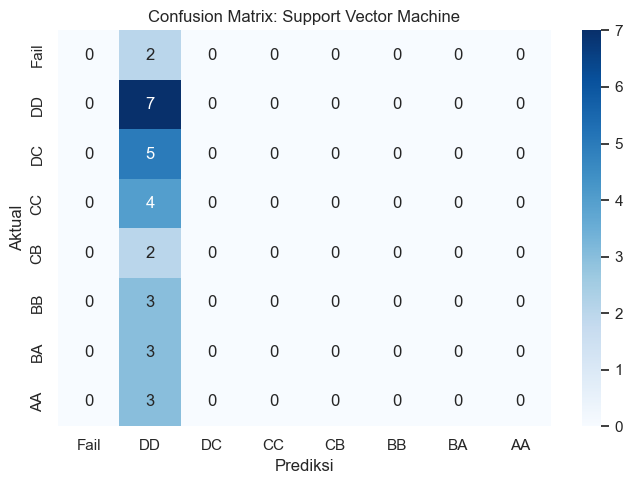

,C,0.1
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [58]:
param_grid_svm = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}
grid_svm = GridSearchCV(SVC(random_state=42), param_grid_svm, cv=5, scoring='accuracy')
grid_svm.fit(X_train_scaled, y_train)

svm_tuned = grid_svm.best_estimator_
train_and_evaluate("Support Vector Machine", svm_tuned, X_train_scaled, X_test_scaled, use_cv_pipeline=True)


## 5. Feature Importance (Random Forest)

Melalui model Random Forest terbaik yang telah dituning, kita dapat melihat fitur mana saja yang memiliki pengaruh paling signifikan terhadap penentuan nilai akhir (*OUTPUT Grade*) mahasiswa.


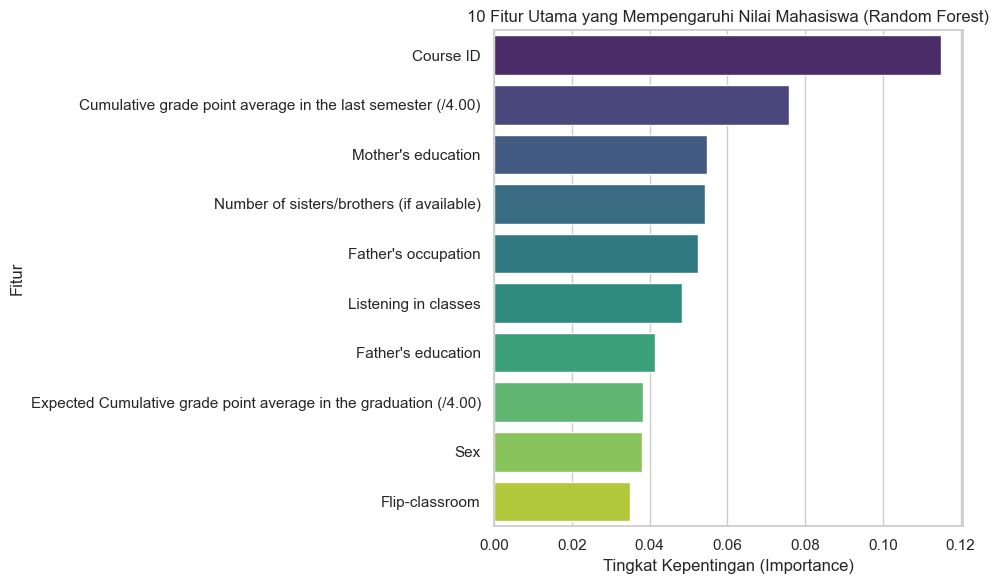

                                              Feature  Importance
30                                          Course ID    0.114840
28  Cumulative grade point average in the last sem...    0.075893
10                                 Mother's education    0.054809
12          Number of sisters/brothers (if available)    0.054270
15                                Father's occupation    0.052576
25                               Listening in classes    0.048257
11                                 Father's education    0.041494
29  Expected Cumulative grade point average in the...    0.038254
1                                                 Sex    0.038051
27                                     Flip-classroom    0.034939


In [59]:
importances = rf_tuned.feature_importances_
feature_names = X.columns

df_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Mengambil 10 Fitur Paling Berpengaruh
top_10_features = df_importance.head(10)

plt.figure(figsize=(10, 6))
sns.barplot(data=top_10_features, x='Importance', y='Feature', palette='viridis')
plt.title("10 Fitur Utama yang Mempengaruhi Nilai Mahasiswa (Random Forest)")
plt.xlabel("Tingkat Kepentingan (Importance)")
plt.ylabel("Fitur")
plt.tight_layout()
plt.show()

print(top_10_features)


## 6. Komparasi Kinerja Model

Kita bandingkan performa masing-masing model yang telah dioptimalkan berdasarkan akurasi testing dan rata-rata akurasi Cross Validation (CV).


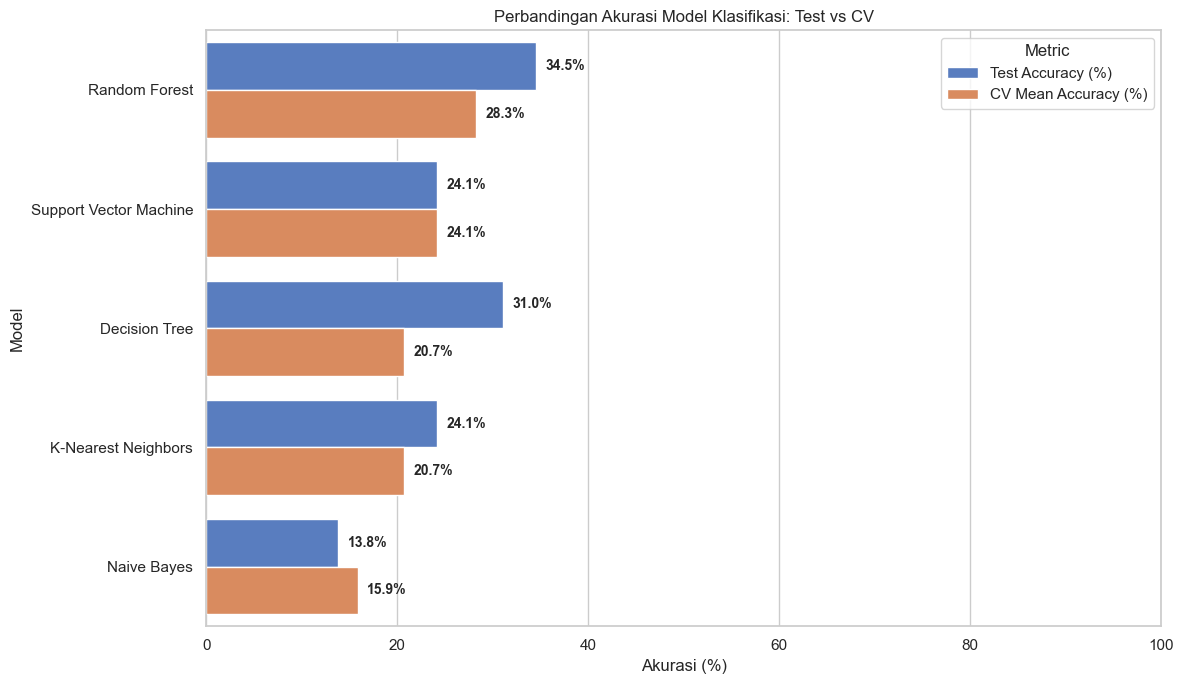

                    Model  Test Accuracy (%)  CV Mean Accuracy (%)
2           Random Forest          34.482759             28.275862
4  Support Vector Machine          24.137931             24.137931
1           Decision Tree          31.034483             20.689655
3     K-Nearest Neighbors          24.137931             20.689655
0             Naive Bayes          13.793103             15.862069


In [60]:
# Membuat DataFrame perbandingan
df_compare = pd.DataFrame({
    'Model': list(model_test_accuracies.keys()),
    'Test Accuracy (%)': [val * 100 for val in model_test_accuracies.values()],
    'CV Mean Accuracy (%)': [val * 100 for val in model_cv_scores.values()]
}).sort_values(by='CV Mean Accuracy (%)', ascending=False)

# Plotting Komparasi
df_melted = pd.melt(df_compare, id_vars="Model", var_name="Metric", value_name="Score")

plt.figure(figsize=(12, 7))
ax = sns.barplot(data=df_melted, x="Score", y="Model", hue="Metric", palette="muted")
plt.title("Perbandingan Akurasi Model Klasifikasi: Test vs CV")
plt.xlabel("Akurasi (%)")
plt.xlim(0, 100)

for p in ax.patches:
    width = p.get_width()
    if width > 0:
        ax.text(width + 1, p.get_y() + p.get_height()/2, f'{width:.1f}%', 
                va='center', ha='left', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print(df_compare)


## 7. Kesimpulan

Berdasarkan hasil analisis dan pemodelan yang dilakukan:
1. **Statistik Deskriptif**: Atribut-atribut mahasiswa bervariasi dengan data kategori ordinal berkisar antara 1-5.
2. **Evaluasi Cross Validation**: Evaluasi 5-Fold Cross Validation memberikan gambaran kinerja model yang jauh lebih stabil karena meminimalisasi bias dari pemisahan train-test split satu kali saja.
3. **Kinerja Model**: Random Forest dan SVM (setelah dilakukan *hyperparameter tuning*) cenderung memberikan keseimbangan antara akurasi uji (*test accuracy*) dan akurasi *Cross Validation* yang lebih konsisten dibandingkan model lainnya.
4. **Faktor Utama**: Berdasarkan analisis *Feature Importance* dari Random Forest, variabel seperti jam belajar mingguan, IPK semester lalu, dan tingkat absensi di kelas merupakan beberapa faktor dominan yang paling mempengaruhi perolehan nilai akhir (*OUTPUT Grade*) mahasiswa.
